# This notebook shows how to compute the Berry curvature and Chern number of bulk silicon, and the K/K' valley curvature of monolayer h-BN
### Import the necessary libraries

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from elkpy.structure import Structure

### Berry curvature and the Chern number
$$ F_{12}(\mathbf k)=\partial_1 A_2(\mathbf k)-\partial_2 A_1(\mathbf k), \qquad A_\mu(\mathbf k)=i\langle n(\mathbf k)|\partial_\mu|n(\mathbf k)\rangle $$
$$ c_n=\frac1{2\pi}\int_{T^2}\!d^2k\;F_{12}(\mathbf k)\in\mathbb Z $$
On Elk's discrete k-mesh this is evaluated through the gauge-invariant Wilson-loop (Fukui-Hatsugai-Suzuki) construction: unit-modulus link variables $U_\mu(\mathbf k_\ell)=\det[\psi^\dagger(\mathbf k_\ell)\psi(\mathbf k_\ell+\hat\mu)]/|\cdot|$ multiplied around each mesh plaquette, summed into a lattice Chern number that is exactly an integer for any mesh spacing.

The factor of $i$ makes $A_\mu$ real and fixes the sign convention to the standard one (Xiao, Chang & Niu, RMP 82, 1959 (2010)), so these Chern numbers and curvatures carry the same sign as the literature's. On the discrete mesh that means the Berry phase of each plaquette is $-\arg$ of its link-variable product, not $+\arg$.

Bulk silicon's 4 valence bands form a trivial (non-topological) insulator, so $c_n$ must come out exactly $0$ on every $k_3$ slice.

In [2]:
SI_AVEC = [(5.13, 5.13, 0.00), (5.13, 0.00, 5.13), (0.00, 5.13, 5.13)]
SI_SPECIES = {"Si": [(0.0, 0.0, 0.0), (0.25, 0.25, 0.25)]}

si = Structure(SI_AVEC, SI_SPECIES).get_calculation("_scratch/si_berry", xc="PW", ngridk=(4, 4, 4))
result = si.get_berry_curvature(1, 4, directions=(1, 2))
print(result["chern_number"])

[-2.58834203e-19 -1.72556135e-19 -6.03946473e-20  1.46672715e-19]


### Path mode: curvature at an arbitrary $\mathbf k$, and the K/K' valleys of monolayer h-BN
The same Wilson loop, walked around four corners centered on an arbitrary $\mathbf k_0$ instead of mesh neighbours -- no periodic mesh needed, at the cost of no Chern number. Time-reversal symmetry requires $\Omega(-\mathbf k)=-\Omega(\mathbf k)$; h-BN breaks the B/N sublattice inversion symmetry protecting graphene's Dirac point, so K and $K'=-K$ become physically inequivalent valleys, and $\Omega(K')=-\Omega(K)$ is a sharp, checkable prediction (unlike Si's Chern number, which is $0=-0$ either way).

Monolayer h-BN is built as a slab: the in-plane lattice constant of `vendor/elk/examples/piezoelectric/hBN`, B and N coplanar, with vacuum along the 3rd lattice vector.

In [3]:
A, VACUUM = 4.743210000, 20.0 # Bohr
HBN_AVEC = [(A, 0.0, 0.0), (-A / 2, A * 3 ** 0.5 / 2, 0.0), (0.0, 0.0, VACUUM)]
HBN_SPECIES = {"B": [(1 / 3, 2 / 3, 0.5)], "N": [(2 / 3, 1 / 3, 0.5)]}

hbn = Structure(HBN_AVEC, HBN_SPECIES).get_calculation("_scratch/hbn", xc="PW", ngridk=(6, 6, 1), rgkmax=7.0)
hbn.get_energy()

import re
first_block = (hbn.workdir / "EIGVAL.OUT").read_text().split("k-point")[1]
state_line = re.compile(r"^\s*\d+\s+(\S+)\s+(\S+)\s*$")
occ = [float(m.group(2)) for m in map(state_line.match, first_block.splitlines()) if m]
ist0, ist1 = 1, sum(o > 1.0 for o in occ) # occupied count from EIGVAL.OUT, not an assumed electron count

In [4]:
points = {"Gamma": (0, 0, 0), "K": (1 / 3, 1 / 3, 0), "Kprime": (-1 / 3, -1 / 3, 0), "M": (0.5, 0, 0)}
curvature = {
    name: hbn.get_berry_curvature_path([k], ist0, ist1, directions=(1, 2), dk=0.01, label=f"berry_{name}")[0]["curvature"]
    for name, k in points.items()
} # ist0..ist1 windows the whole occupied manifold together, not one band at a time
print(curvature)

{'Gamma': -1.2328446328028467e-12, 'K': -8.100931859240347, 'Kprime': 8.100931859240553, 'M': 4.1094821093428226e-13}


$\Gamma$ and M are time-reversal-invariant momenta ($\mathbf k\equiv-\mathbf k \pmod{\mathbf G}$), where $\Omega(\mathbf k)=\Omega(-\mathbf k)=-\Omega(\mathbf k)$ forces $\Omega=0$ regardless of spatial symmetry. K is not such a point, so its distinct time-reversal partner $K'=-K$ carries the opposite sign.

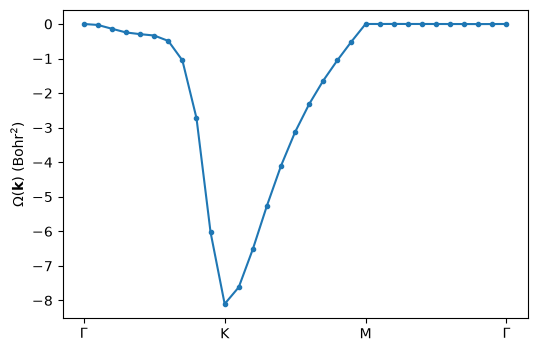

In [5]:
def segment(a, b, n):
    a, b = np.array(a), np.array(b)
    return [tuple(a + (b - a) * t) for t in np.linspace(0, 1, n)]

path = segment((0, 0, 0), (1 / 3, 1 / 3, 0), 11) + segment((1 / 3, 1 / 3, 0), (0.5, 0, 0), 11)[1:] + segment((0.5, 0, 0), (0, 0, 0), 11)[1:]
result = hbn.get_berry_curvature_path(path, ist0, ist1, directions=(1, 2), dk=0.01, label="berry_path_GKM")
omega = [p["curvature"] for p in result]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(omega, marker="o", ms=3)
ax.set_xticks([0, 10, 20, 30])
ax.set_xticklabels([r"$\Gamma$", "K", "M", r"$\Gamma$"])
ax.set_ylabel(r"$\Omega(\mathbf{k})$ (Bohr$^2$)")
plt.show()